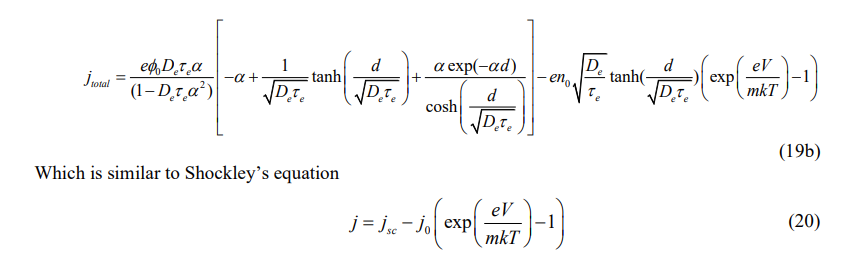


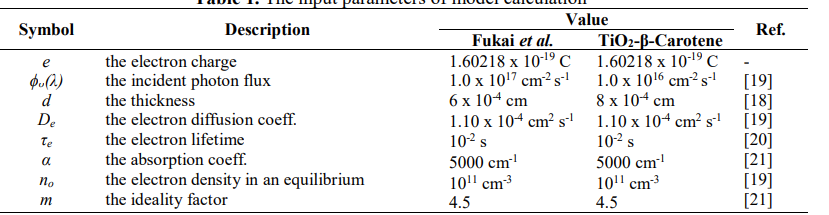



In [21]:
import numpy as np 
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt 
import scienceplots
plt.style.use(['science','no-latex','ieee'])
import functions as f
#import warnings

#import parameters value from reference tabble above
e, kB, phi_0, d, T, alpha, m, n_0, tau_e, D_e = (
    f.parameters_value_from_reference()
    )
file = "./data/shakinah.xlsx"
data = [pd.read_excel(file,sheet,header=2)  for sheet in pd.ExcelFile(file).sheet_names]
sheet_num = 1
jsc_from_data = data[sheet_num].iloc[data[sheet_num]["WE(1).Potential (V)"].abs().idxmin(), 2]
I,V =data[sheet_num]["mili A"], data[sheet_num]["WE(1).Potential (V)"]

AREA = f.area()
J_data = (I / 1000.0) / AREA

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


Fit converged!
m     = 2.360
n_0   = 1.595e+17 cm^-3
tau_e = 1.224e+01 s
D_e   = 3.545e-01 cm^2/s


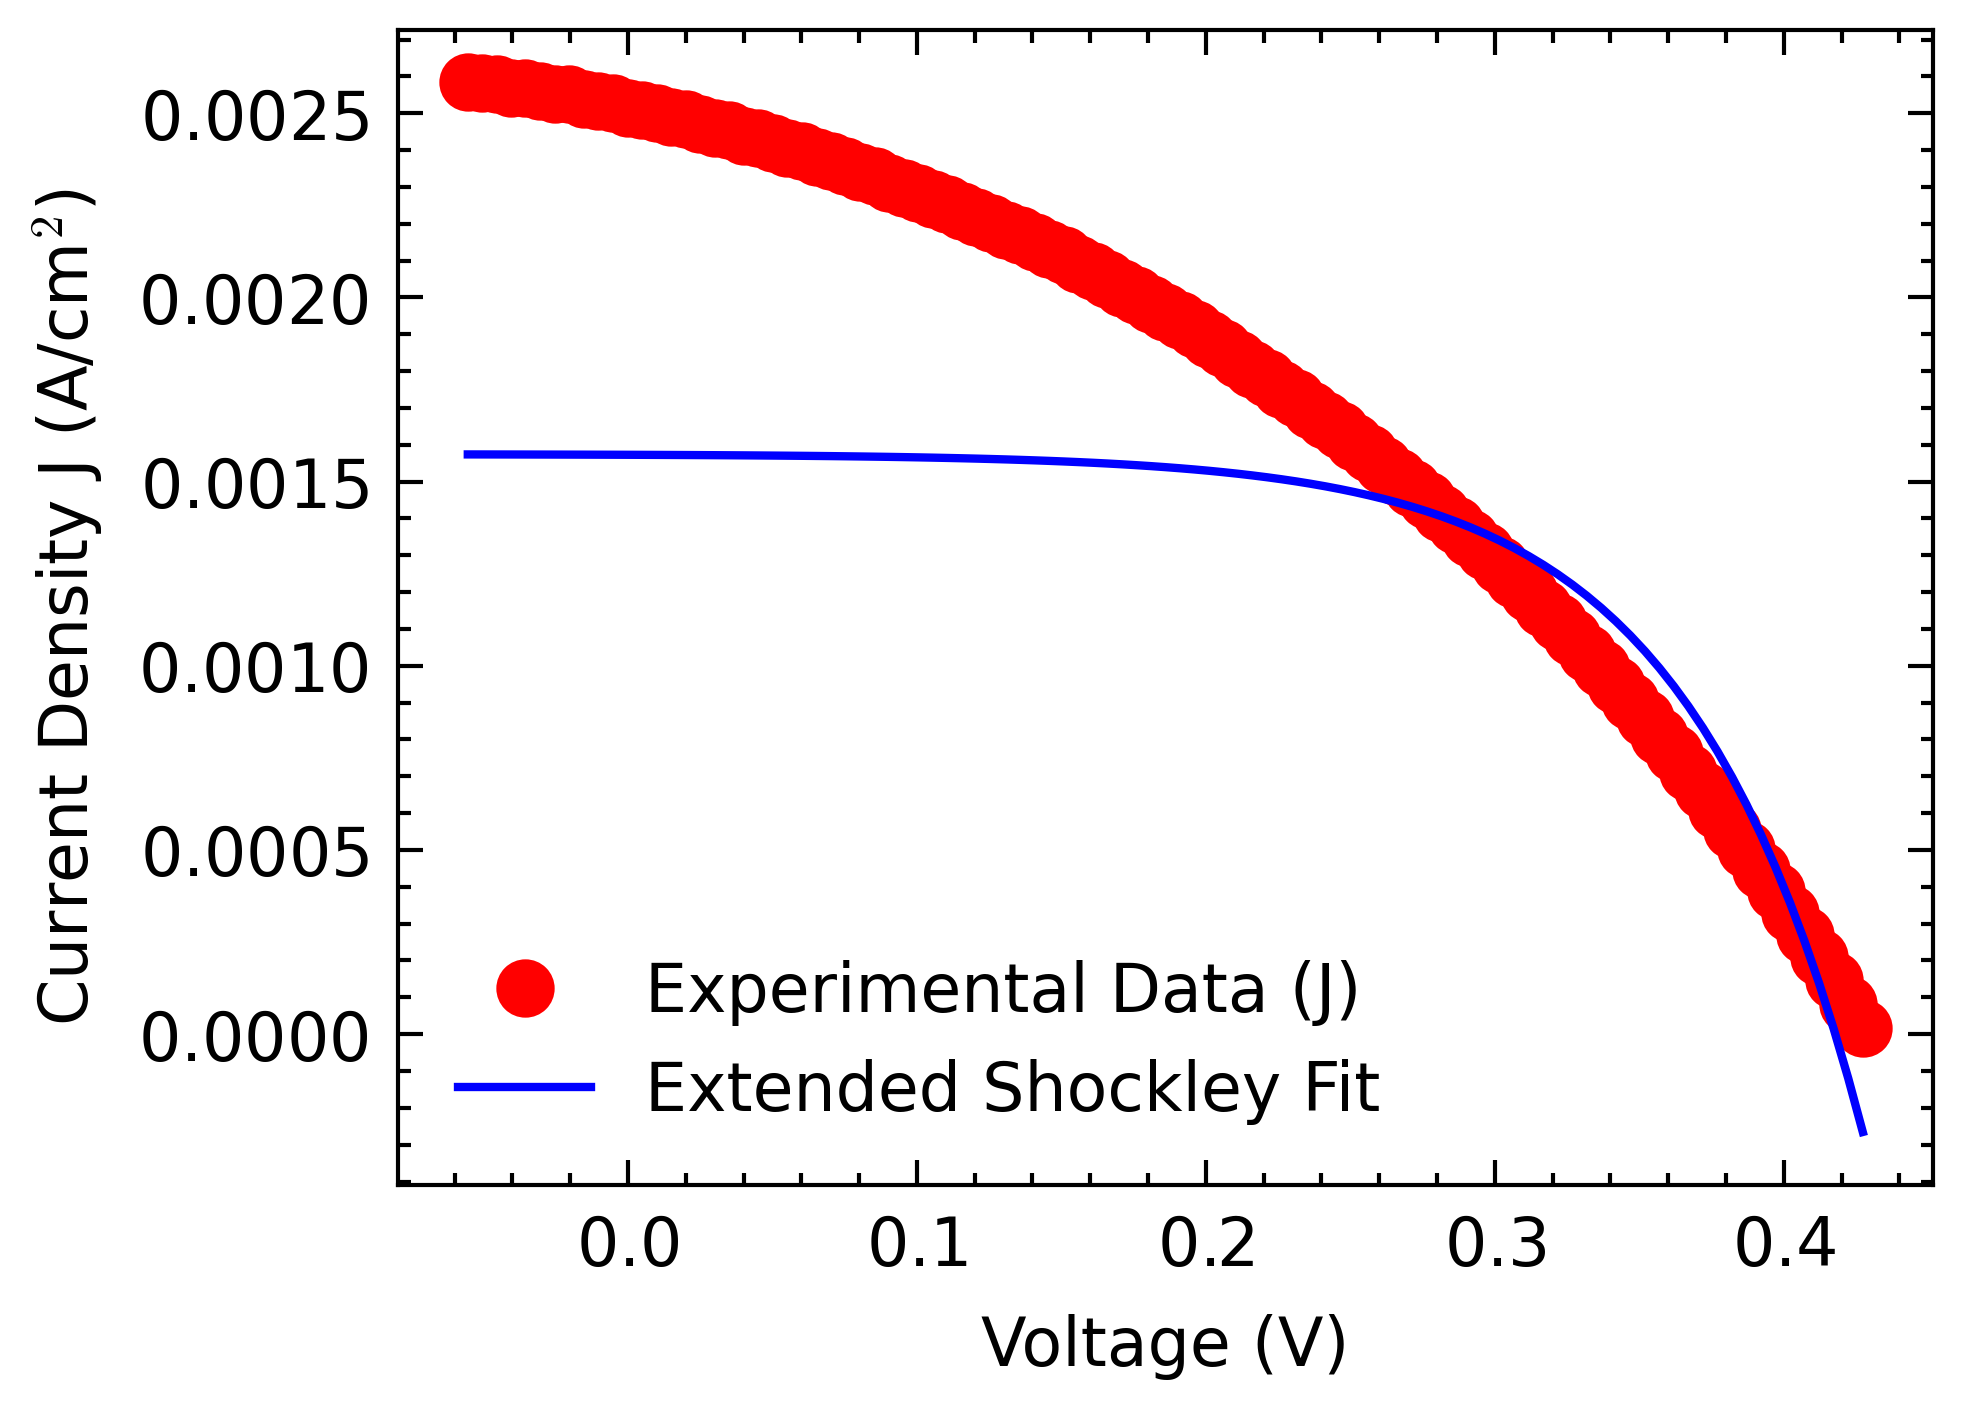

In [23]:
def scaled_shockley(V, m, n0_scaled, tau_scaled, D_scaled):
    return f.diffusion_model_shockley(V, m, n0_scaled*1e14, tau_scaled*1e-2, D_scaled*1e-4)

initial_guess_scaled = [m, 1.0, 1.0, 1.0]

low_lim_scaled = [1.0, 1e-6, 1e-6, 1e-6]
up_lim_scaled = [20.0, 1e6, 1e6, 1e6] 

try:
    params_s, covs_s, info1, info2, info3 = optimize.curve_fit(
        scaled_shockley, V, J_data, 
        p0=initial_guess_scaled, 
        bounds=(low_lim_scaled, up_lim_scaled),
        full_output=True,
        method='trf',
        loss='cauchy'
    )
    print("Fit converged!")
    print(f"m     = {params_s[0]:.3f}")
    print(f"n_0   = {params_s[1]*1e14:.3e} cm^-3")
    print(f"tau_e = {params_s[2]*1e-2:.3e} s")
    print(f"D_e   = {params_s[3]*1e-4:.3e} cm^2/s")

    plt.figure()
    plt.plot(V, J_data, 'ro', label='Experimental Data (J)')
    plt.plot(V, scaled_shockley(V, *params_s), 'b-', label='Extended Shockley Fit')
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density J (A/cm$^2$)")
    plt.legend()
    plt.show()
    
   
except Exception as e:
    print("Failed to converge. Error:", e)

In [14]:
errors = np.sqrt(np.diag(covs_s))
correlation_matrix = covs_s / np.outer(errors, errors)
print(correlation_matrix)

[[ 1.          0.99658766 -0.99057117  0.98730674]
 [ 0.99658766  1.         -0.99832725  0.99704731]
 [-0.99057117 -0.99832725  1.         -0.99942481]
 [ 0.98730674  0.99704731 -0.99942481  1.        ]]
